In [203]:
import sklearn as skl
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [ ]:
pupil_svm = pd.read_csv("")
print(pupil_svm[:10])

   Unnamed: 0  RECORDING_SESSION_LABEL  TRIAL_INDEX   rel_pup  LEFT_GAZE_X  \
0           1                     2015           47 -0.424625        813.7   
1           2                     2015           47 -0.416647        815.1   
2           3                     2015           47 -0.369224        817.0   
3           4                     2015           47 -0.330270        816.1   
4           5                     2015           47 -0.284176        809.1   
5           6                     2015           47 -0.149858        665.3   
6           7                     2015           47 -0.149858        571.9   
7           8                     2015           47 -0.149858        573.5   
8           9                     2015           47 -0.149858        576.5   
9          10                     2015           47 -0.149858        625.0   

   LEFT_GAZE_Y trialOrder  block  new_time trialDirection  
0        574.1        LMR      2         0             LR  
1        574.5       

In my previous analyses I used: "First, we explored the period starting from 1000 ms after the onset of the first image and extending until half a second after the end of the third image, corresponding to a 5000 ms period. This 1000 ms delay was implemented because the cognitive pupil dilation response emerges slowly (Hoeks & Levelt, 1993; Mathôt & Vilotijević, 2023). For the same reason, we included half a second period after the offset of the third image to capture responses to the third image ".

This would correspond to 3000-8500 ms

What the SVM actually needs is the whole trajectory as one feature vector:
[-0.42, -0.41, -0.36, ..., -0.10]  → LR   # one row = one full trial
[-0.42, -0.41, -0.37, ...,  0.45]  → RL   # diverges later in the timeseries


In [206]:
cols = ['RECORDING_SESSION_LABEL', 'TRIAL_INDEX', 'rel_pup', 'new_time', 'trialDirection']
pup_simple = pupil_svm[cols]

pup_simple = pup_simple[(pup_simple['new_time'] >= 3000) & (pup_simple['new_time'] <= 8500)]

print(pup_simple["trialDirection"].unique())
print(pup_simple["RECORDING_SESSION_LABEL"].unique())
print(len(pup_simple["new_time"].unique()))
print(pup_simple[:10])
print(f"Rows: {len(pup_simple)}")

# Remove participants with 20 or fewer encoding trials
trials_per_participant = pup_simple.groupby('RECORDING_SESSION_LABEL')['TRIAL_INDEX'].nunique()
valid_participants = trials_per_participant[trials_per_participant > 20].index.tolist()

print(f"Removing: {trials_per_participant[trials_per_participant <= 20].to_dict()}")
print(f"Keeping {len(valid_participants)} participants")

pup_simple = pup_simple[pup_simple['RECORDING_SESSION_LABEL'].isin(valid_participants)]

['LR' 'NL' 'RL']
[2015 2016 2017 2019 2020 2021 2023 2024 2025 2026 2027 2028 2029 2030
 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044
 2045 2047 2048 2049 2050]
111
    RECORDING_SESSION_LABEL  TRIAL_INDEX   rel_pup  new_time trialDirection
60                     2015           47  0.114618      3000             LR
61                     2015           47  0.115883      3050             LR
62                     2015           47  0.117148      3100             LR
63                     2015           47  0.118413      3150             LR
64                     2015           47  0.119677      3200             LR
65                     2015           47  0.120941      3250             LR
66                     2015           47  0.122204      3300             LR
67                     2015           47  0.123467      3350             LR
68                     2015           47  0.123467      3400             LR
69                     2015           47  0.107719

In [207]:
# Create a unique trial key (participant + trial bs trial indices repeat) 
pup_simple['trial_key'] = (
    pup_simple['RECORDING_SESSION_LABEL'].astype(str) + '_' + 
    pup_simple['TRIAL_INDEX'].astype(str)
)

# Pivot to wide format
trial_wide = pup_simple.pivot_table(
    index='trial_key',
    columns='new_time',
    values='rel_pup'
)

# Then get labels per trial
labels = pup_simple.groupby('trial_key')['trialDirection'].first()
labels = labels.loc[trial_wide.index]  # make sure order matches

print(trial_wide.shape)   # should be (n_trials, n_timepoints)
print(trial_wide.head())
print(labels.value_counts())

(1107, 111)
new_time       3000      3050      3100      3150      3200      3250  \
trial_key                                                               
2016_10   -0.243305 -0.241977 -0.240650 -0.240650 -0.240650 -0.115067   
2016_12   -0.012449 -0.012449 -0.012449 -0.012449 -0.012449 -0.003096   
2016_13   -0.251591 -0.276007 -0.300548 -0.325216 -0.350012 -0.350012   
2016_14    0.151933  0.121941  0.096800  0.066450  0.046106  0.025672   
2016_16    0.107717  0.112349  0.126218  0.135443  0.140049  0.144651   

new_time       3300      3350      3400      3450  ...      8050      8100  \
trial_key                                          ...                       
2016_10   -0.068858 -0.038308 -0.002919  0.022195  ...  0.237657  0.170142   
2016_12    0.015558  0.043410  0.094080  0.098661  ...  0.322738  0.322738   
2016_13   -0.350012 -0.295630 -0.241859 -0.203126  ... -0.193491 -0.237001   
2016_14    0.005146 -0.005152 -0.025817 -0.041378  ... -0.200040 -0.194658   
2016_16 

33 participants
111 timepoints per trial (3000 ms to 8500 0ms in 50ms steps)
LR: 384, RL: 382 NL: 388 trials, chance around 33%

In [208]:
# Define your feat names (X)
# .values converts the Pandas column into a clean Numpy array for the SVM
pup_featdata = trial_wide.values                        # shape: (1154, 301)
pup_targdata = labels.values                            # shape: (1154,) — string labels

print(f"pup_featdata shape: {pup_featdata.shape}")
print(f"pup_targdata shape: {pup_targdata.shape}")
print(f"Any missing values? {np.isnan(pup_featdata).any()}")


print(pup_featdata[:10])
print(pup_targdata)

pup_featdata shape: (1107, 111)
pup_targdata shape: (1107,)
Any missing values? False
[[-0.24330455 -0.24197724 -0.24065032 ...  0.12133454  0.12133454
   0.12623768]
 [-0.01244893 -0.01244893 -0.01244893 ...  0.33150669  0.34244696
   0.35336499]
 [-0.25159122 -0.27600723 -0.30054814 ... -0.17907389 -0.13607469
  -0.11234727]
 ...
 [-0.10448026 -0.10448026 -0.10448026 ...  0.00983147  0.04408362
   0.06840108]
 [-0.11261036 -0.09187427 -0.07123243 ...  0.33778051  0.33778051
   0.33778051]
 [-0.10120422 -0.10120422 -0.10120422 ... -0.05203609 -0.02496054
   0.02335555]]
['LR' 'RL' 'RL' ... 'NL' 'NL' 'NL']


In [209]:
# Randomly select 75% of the rows to be in the training dataset.
all_rows = np.arange(pup_featdata.shape[0])
n_train = int(round(len(all_rows) * 0.75))
train_rows = np.random.choice(all_rows, n_train, replace=False)
test_rows = np.setdiff1d(all_rows, train_rows)

# Extract these rows into separate matrices:
train_featdata = pup_featdata[train_rows]
train_targdata = pup_targdata[train_rows]
test_featdata  = pup_featdata[test_rows]
test_targdata  = pup_targdata[test_rows]

# Look at them 
print(f"Training trials: {len(train_rows)}")
print(f"Test trials:     {len(test_rows)}")


Training trials: 830
Test trials:     277


In [210]:
# Also need to normalize/scale data
scaler = StandardScaler()
train_featdata_scaled = scaler.fit_transform(train_featdata)
test_featdata_scaled  = scaler.transform(test_featdata)

print(train_featdata_scaled[:10])
print(train_featdata_scaled.mean(axis=0))
print(train_featdata_scaled.std(axis=0))

print(test_featdata_scaled[:10])
print(test_featdata_scaled.mean(axis=0))
print(test_featdata_scaled.std(axis=0))

[[-0.02051235 -0.02395693 -0.18715201 ...  0.66704787  0.69038577
   0.69803612]
 [-0.28271018 -0.31729889 -0.3609047  ... -0.40181269 -0.40742363
  -0.41300034]
 [ 2.70778237  2.64285024  2.57605654 ... -3.28050155 -3.33338565
  -3.38574964]
 ...
 [ 0.47502573  0.48128621  0.47782237 ... -0.23974272 -0.16562923
  -0.12091987]
 [ 1.21876121  1.31785204  1.36454572 ... -1.7570301  -1.79858227
  -1.78580796]
 [-0.6947068  -0.68355275 -0.71606583 ...  1.04431692  1.11188789
   1.09119087]]
[ 3.14825141e-16  6.21925537e-16 -1.48241526e-16 -4.37401119e-17
  2.54715927e-16  1.65797764e-16 -4.29509173e-16 -1.68874285e-16
 -5.15852421e-16 -2.90931937e-17 -1.55163700e-17 -2.40771258e-17
 -1.50147632e-16  1.21255081e-16 -3.64500933e-16 -3.06047022e-16
  3.64400611e-16  2.88908790e-16 -3.31800350e-16 -3.04140916e-17
  2.07297365e-16  4.38203690e-16 -2.08802186e-16 -1.67603548e-16
 -8.82827947e-17 -1.73622830e-16 -1.44061470e-16 -2.04388046e-16
 -2.34083168e-16  4.73516808e-17  1.86999011e-16  4.1

In [211]:
# Train now
svm_rbf = skl.svm.SVC(kernel='rbf', class_weight='balanced') # using rbf kernel instead of linear
svm_rbf.fit(train_featdata_scaled, train_targdata)

SVC(class_weight='balanced')

In [212]:
# Evaluate
accuracy = svm_rbf.score(test_featdata_scaled, test_targdata)
print(f"\nTest accuracy: {accuracy:.3f}  (chance = 0.33)")


Test accuracy: 0.484  (chance = 0.33)


Can predict above chance!

In [213]:
from sklearn.metrics import classification_report

y_pred = svm_rbf.predict(test_featdata_scaled)
print(classification_report(test_targdata, y_pred))

              precision    recall  f1-score   support

          LR       0.46      0.44      0.45        85
          NL       0.49      0.67      0.57        94
          RL       0.50      0.35      0.41        98

    accuracy                           0.48       277
   macro avg       0.48      0.48      0.47       277
weighted avg       0.48      0.48      0.47       277



In [214]:
print(len(test_targdata))
print(len(y_pred))

277
277


Let's plot a confusion matrix to see what the predictions look like

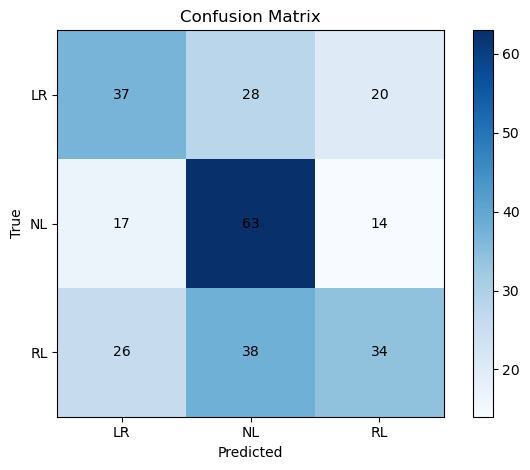

In [215]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_targdata, y_pred, labels=['LR', 'NL', 'RL'])

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')

labels_order = ['LR', 'NL', 'RL']
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels_order)
ax.set_yticklabels(labels_order)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

NL is the easiest to identify
LR and RL seem to be similar in how well they are identified. 
'confusion' for LR and RL trials seems to be evenly spread between the RL/NL and LR/NL trials. 

Would these patterns look drastically different if I analyzed over another time period?
A good sanity check is to try a few windows and see if the pattern is consistent use the same train/test rows but different time windows and train


In [ ]:
cols = ['RECORDING_SESSION_LABEL', 'TRIAL_INDEX', 'rel_pup', 'new_time', 'trialDirection']
pup_simple = pupil_svm[cols]

# Remove participants with 20 or fewer encoding trials
trials_per_participant = pup_simple.groupby('RECORDING_SESSION_LABEL')['TRIAL_INDEX'].nunique()
valid_participants = trials_per_participant[trials_per_participant > 20].index.tolist()
pup_simple = pup_simple[pup_simple['RECORDING_SESSION_LABEL'].isin(valid_participants)]

# Create a unique trial key (participant + trial bs trial indices repeat) 
pup_simple['trial_key'] = (
    pup_simple['RECORDING_SESSION_LABEL'].astype(str) + '_' + 
    pup_simple['TRIAL_INDEX'].astype(str)
)

# Pivot to wide format
trial_wide = pup_simple.pivot_table(
    index='trial_key',
    columns='new_time',
    values='rel_pup'
)

# Then get labels per trial
labels = pup_simple.groupby('trial_key')['trialDirection'].first()
labels = labels.loc[trial_wide.index]  # make sure order matches

np.random.seed(0)
all_rows = np.arange(len(labels))
n_train = int(round(len(all_rows) * 0.75))
train_rows = np.random.choice(all_rows, n_train, replace=False)
test_rows = np.setdiff1d(all_rows, train_rows)

pup_targdata = labels.values

for start, end in [(1000, 8500), (2000, 8500), (3000, 8500), (3000, 9500)]:
    # Subset timepoints
    time_mask = (trial_wide.columns >= start) & (trial_wide.columns <= end)
    pup_featdata = trial_wide.loc[:, time_mask].values
    
    # Split
    train_featdata = pup_featdata[train_rows]
    train_targdata = pup_targdata[train_rows]
    test_featdata  = pup_featdata[test_rows]
    test_targdata  = pup_targdata[test_rows]
    
    # Scale
    scaler = StandardScaler()
    train_featdata_scaled = scaler.fit_transform(train_featdata)
    test_featdata_scaled  = scaler.transform(test_featdata)
    
    # Train & evaluate
    svm_rbf = skl.svm.SVC(kernel='rbf', class_weight='balanced')
    svm_rbf.fit(train_featdata_scaled, train_targdata)
    accuracy = svm_rbf.score(test_featdata_scaled, test_targdata)
    
    print(f"{start}-{end}ms  |  timepoints: {time_mask.sum()}  |  accuracy: {accuracy:.3f}")

1000-8500ms  |  timepoints: 151  |  accuracy: 0.469
2000-8500ms  |  timepoints: 131  |  accuracy: 0.480
3000-8500ms  |  timepoints: 111  |  accuracy: 0.502
3000-9500ms  |  timepoints: 131  |  accuracy: 0.513


Seems good, nothing drastically different

Now let's try the participant-based approach: the model will be trained on all participants but one, and then tested on one!

In [217]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report
import numpy as np

# Get participant ID aligned to trial_wide index
# We need to know which participant each trial belongs to so we can hold out one participant at a time
trial_participant = pup_simple.groupby('trial_key')['RECORDING_SESSION_LABEL'].first()
trial_participant = trial_participant.loc[trial_wide.index]
participant_groups = trial_participant.values

# Get matrix using the analysis window
time_mask = (trial_wide.columns >= 3000) & (trial_wide.columns <= 8500)
pup_featdata = trial_wide.loc[:, time_mask].values  # shape: (1154, 111)
pup_targdata = labels.values    

LeaveOneGroupOut splits the data so that each fold holds out one participant entirely while the model trains on all other participants.
Then it tests it out on the one that was out.
Overall results are across all though

In [ ]:
logo = LeaveOneGroupOut()

# Store all predictions here as it iterates through the participants
all_predictions = np.zeros(len(pup_targdata), dtype=object)

# Each iteration holds out one participant:
for train_idx, test_idx in logo.split(pup_featdata, pup_targdata, participant_groups):
    
    # Split into train (all other participants) and test (held-out participant)
    train_featdata = pup_featdata[train_idx]
    test_featdata  = pup_featdata[test_idx]
    train_targdata = pup_targdata[train_idx]
    test_targdata  = pup_targdata[test_idx]
    
    # Scale using only training data statistics
    scaler = StandardScaler()
    train_featdata_scaled = scaler.fit_transform(train_featdata)
    test_featdata_scaled  = scaler.transform(test_featdata)
    
    # Train on all participants except the one
    svm_rbf = skl.svm.SVC(kernel='rbf', class_weight='balanced')
    svm_rbf.fit(train_featdata_scaled, train_targdata)
    
    # Predict for the held-out participant and store results
    all_predictions[test_idx] = svm_rbf.predict(test_featdata_scaled)

# Overall results across all participants:
# all_predictions now contains predictions for every trial, each predicted by a model that never saw that participant during training
accuracy = np.mean(all_predictions == pup_targdata)
print(f"LOPO Accuracy: {accuracy:.3f}  (chance = 0.33)")
print(classification_report(pup_targdata, all_predictions))

LOPO Accuracy: 0.464  (chance = 0.33)
              precision    recall  f1-score   support

          LR       0.48      0.46      0.47       368
          NL       0.50      0.58      0.54       371
          RL       0.40      0.36      0.38       368

    accuracy                           0.46      1107
   macro avg       0.46      0.46      0.46      1107
weighted avg       0.46      0.46      0.46      1107



In [219]:
# Per-participant accuracy
for participant in np.unique(participant_groups):
    participant_mask = (participant_groups == participant)
    participant_acc = np.mean(
        all_predictions[participant_mask] == pup_targdata[participant_mask]
    )
    n_trials = participant_mask.sum()
    print(f"Participant {participant}: accuracy = {participant_acc:.3f}  (n={n_trials})")

Participant 2016: accuracy = 0.444  (n=36)
Participant 2017: accuracy = 0.316  (n=38)
Participant 2020: accuracy = 0.222  (n=36)
Participant 2021: accuracy = 0.514  (n=37)
Participant 2023: accuracy = 0.583  (n=36)
Participant 2024: accuracy = 0.447  (n=38)
Participant 2025: accuracy = 0.543  (n=35)
Participant 2026: accuracy = 0.528  (n=36)
Participant 2027: accuracy = 0.306  (n=36)
Participant 2028: accuracy = 0.351  (n=37)
Participant 2029: accuracy = 0.459  (n=37)
Participant 2030: accuracy = 0.263  (n=38)
Participant 2031: accuracy = 0.529  (n=34)
Participant 2032: accuracy = 0.553  (n=38)
Participant 2033: accuracy = 0.459  (n=37)
Participant 2034: accuracy = 0.351  (n=37)
Participant 2035: accuracy = 0.525  (n=40)
Participant 2036: accuracy = 0.564  (n=39)
Participant 2037: accuracy = 0.500  (n=36)
Participant 2038: accuracy = 0.457  (n=35)
Participant 2039: accuracy = 0.605  (n=38)
Participant 2040: accuracy = 0.684  (n=38)
Participant 2041: accuracy = 0.541  (n=37)
Participant

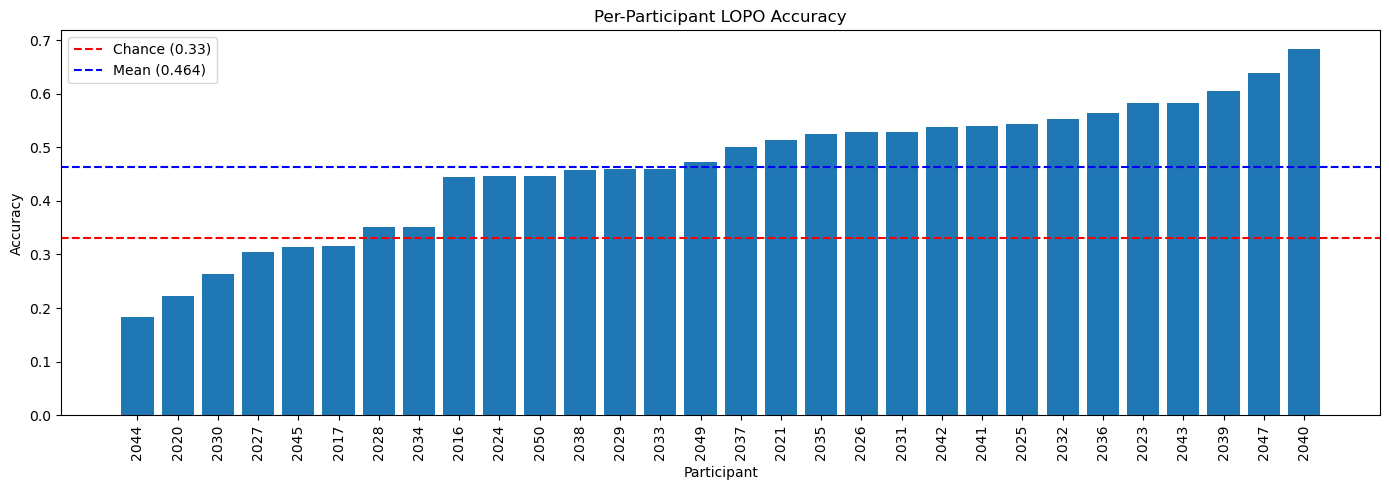

In [220]:
participants = list(np.unique(participant_groups))
accs = [np.mean(all_predictions[participant_groups == p] == pup_targdata[participant_groups == p]) 
        for p in participants]

sorted_pairs = sorted(zip(accs, participants))
sorted_accs, sorted_participants = zip(*sorted_pairs)

plt.figure(figsize=(14, 5))
plt.bar(range(len(sorted_participants)), sorted_accs)
plt.axhline(0.33, color='red', linestyle='--', label='Chance (0.33)')
plt.axhline(np.mean(accs), color='blue', linestyle='--', label=f'Mean ({np.mean(accs):.3f})')
plt.xticks(range(len(sorted_participants)), sorted_participants, rotation=90)
plt.xlabel('Participant')
plt.ylabel('Accuracy')
plt.title('Per-Participant LOPO Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Is the pattern consistent across participants?

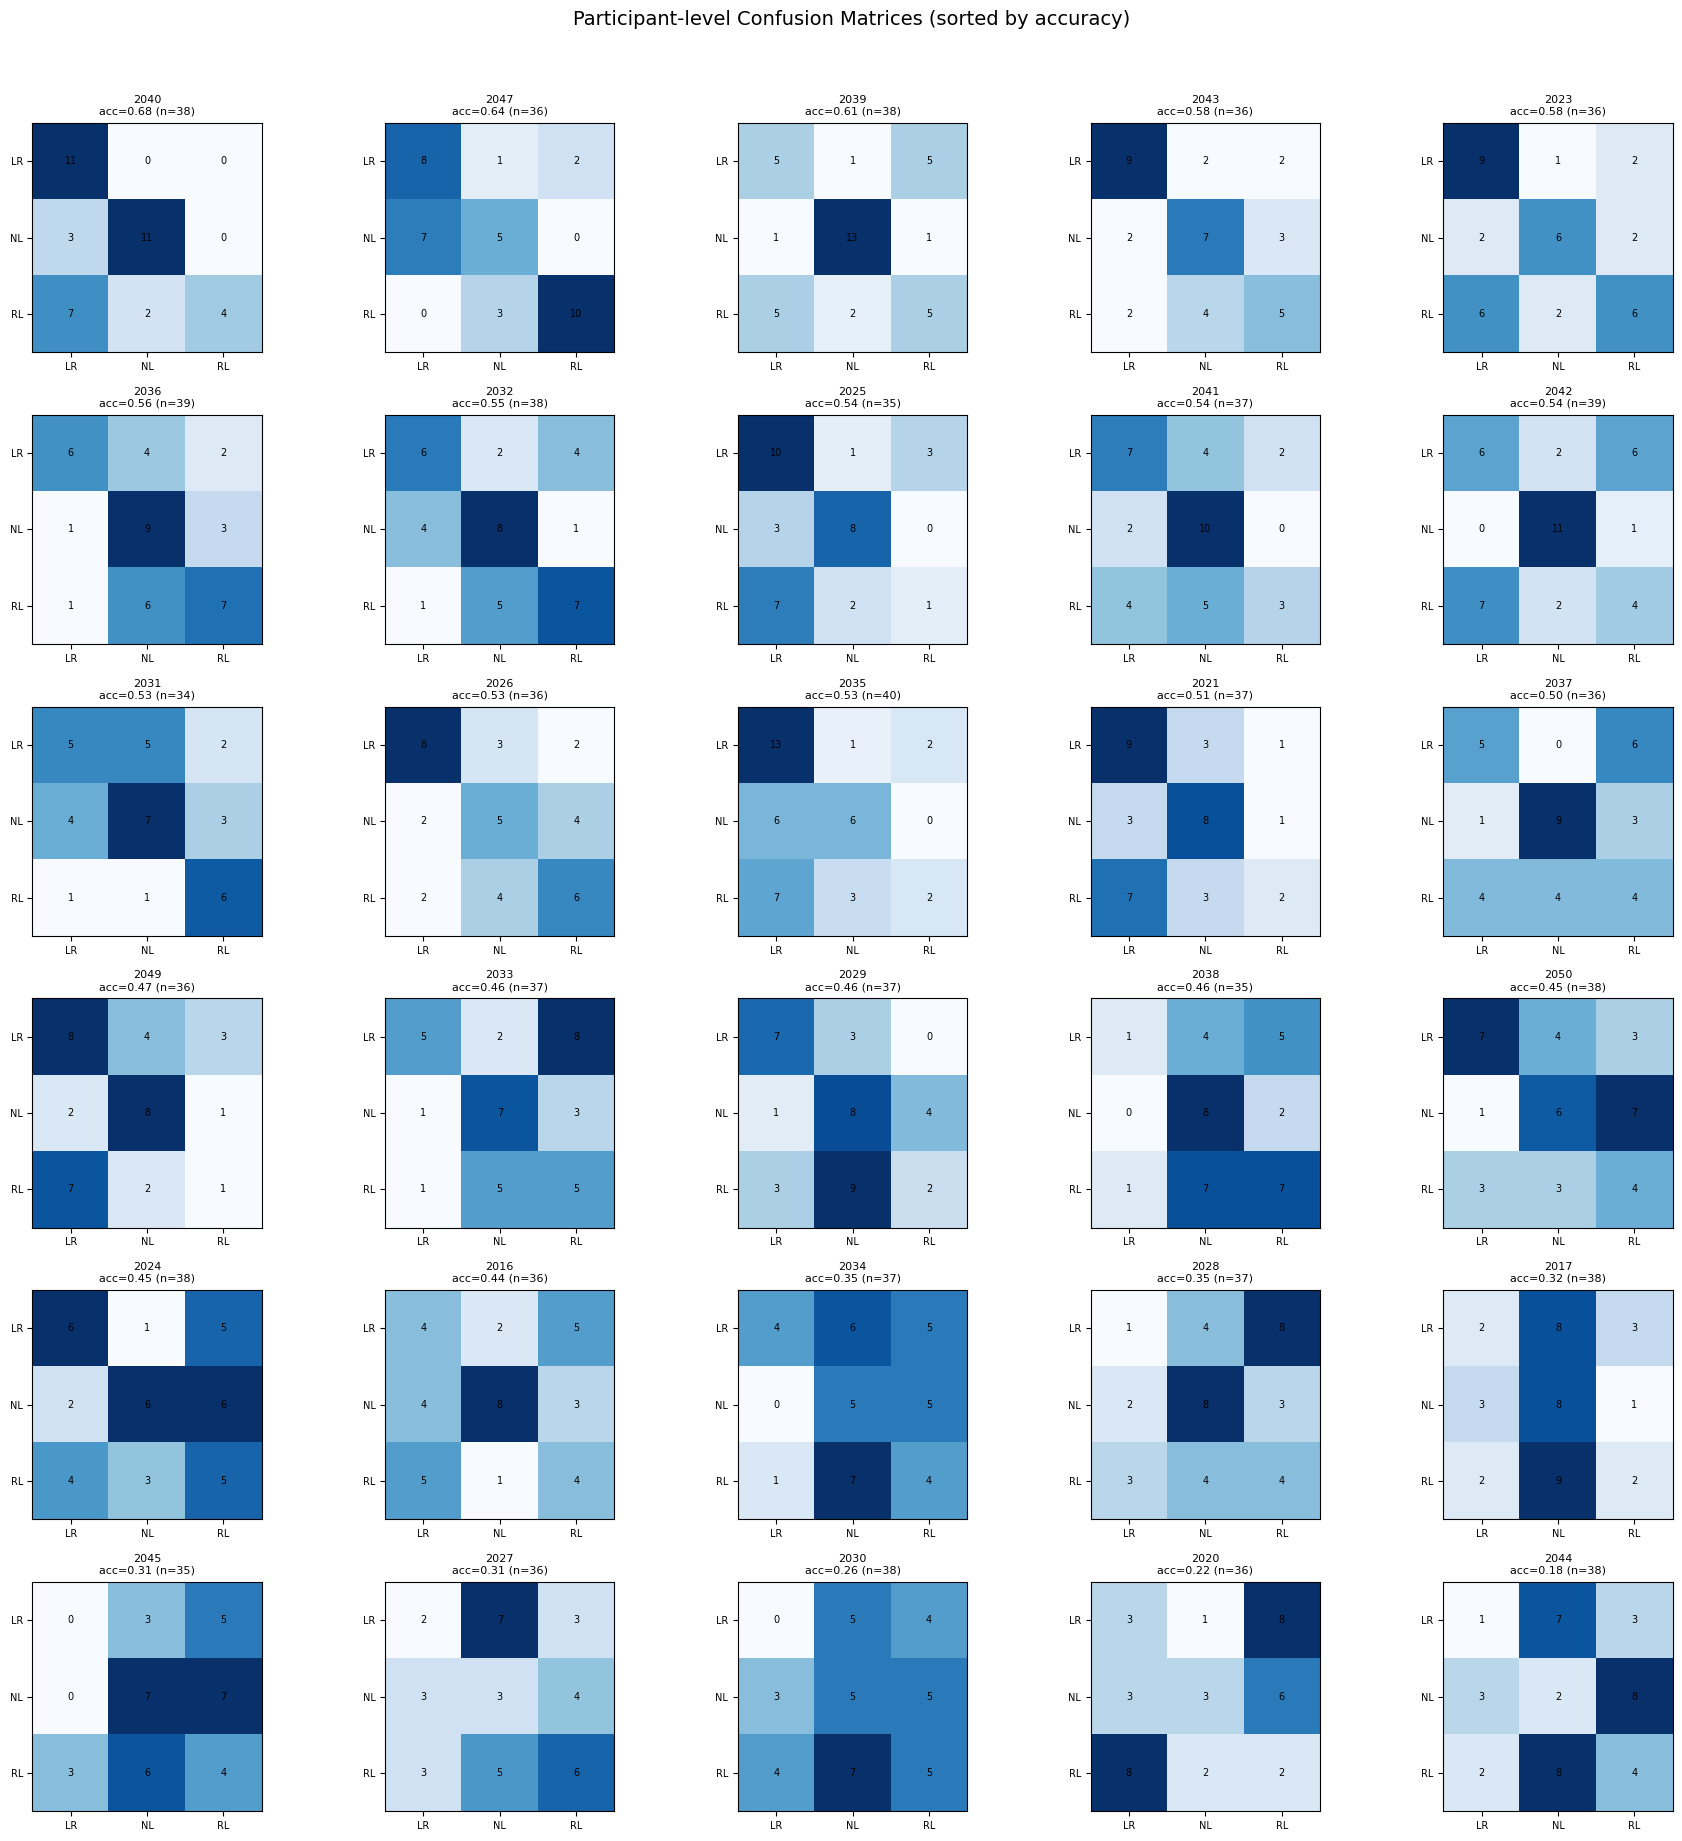

In [541]:
# First compute per-participant accuracy and sort
participant_results_pup = []
for participant in np.unique(participant_groups):
    p_mask = participant_groups == participant
    p_true = pup_targdata[p_mask]
    p_pred = all_predictions[p_mask]
    acc = np.mean(p_pred == p_true)
    participant_results_pup.append((acc, participant))

participant_results_pup_sorted = sorted(participant_results_pup, reverse=True)

n_cols = 5
n_rows = int(np.ceil(len(participant_results_pup_sorted) / n_cols))
labels_order = ['LR', 'NL', 'RL']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, (acc, participant) in enumerate(participant_results_pup_sorted):
    p_mask = participant_groups == participant
    p_true = pup_targdata[p_mask]
    p_pred = all_predictions[p_mask]
    
    cm = confusion_matrix(p_true, p_pred, labels=labels_order)
    
    axes[i].imshow(cm, cmap='Blues')
    axes[i].set_xticks(range(3))
    axes[i].set_yticks(range(3))
    axes[i].set_xticklabels(labels_order, fontsize=7)
    axes[i].set_yticklabels(labels_order, fontsize=7)
    axes[i].set_title(f'{participant}\nacc={acc:.2f} (n={p_mask.sum()})', fontsize=8)
    
    for row in range(3):
        for col in range(3):
            axes[i].text(col, row, cm[row, col],
                        ha='center', va='center', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Participant-level Confusion Matrices (sorted by accuracy)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


A lot of variability among participants. 

maybe try with accuracy now,  SVM models should be doing better with nonlinear relationships

In [ ]:

recall =  pd.read_csv("")

cols = ['RECORDING_SESSION_LABEL','TRIAL_INDEX', 'orderResponse', 'encoding_order', 'encoding_position', 'is_correct', 'originEncodingTrial', 'originTrialDir']
recall = recall[cols]


print(recall.columns.tolist())
print(recall.head())
print(recall['is_correct'].value_counts())

recall_clean = recall.drop_duplicates(
    subset=['RECORDING_SESSION_LABEL', 'originEncodingTrial']
)

print(recall_clean.shape)
print(recall_clean['is_correct'].value_counts())

['RECORDING_SESSION_LABEL', 'TRIAL_INDEX', 'orderResponse', 'encoding_order', 'encoding_position', 'is_correct', 'originEncodingTrial', 'originTrialDir']
   RECORDING_SESSION_LABEL  TRIAL_INDEX orderResponse encoding_order  \
0                     2015           28         first          first   
1                     2015           28         first          first   
2                     2015           28         first          first   
3                     2015           28         first          first   
4                     2015           28         first          first   

  encoding_position  is_correct  originEncodingTrial originTrialDir  
0                 M         1.0                 20.0             NL  
1                 M         1.0                 20.0             NL  
2                 M         1.0                 20.0             NL  
3                 M         1.0                 20.0             NL  
4                 M         1.0                 20.0           

In [543]:
# Remove nas
recall_clean = recall_clean.dropna(subset=['originEncodingTrial'])

# get keys again to know trial/participant combos
recall_clean['trial_key'] = (
    recall_clean['RECORDING_SESSION_LABEL'].astype(str) + '_' +
    recall_clean['originEncodingTrial'].astype(int).astype(str)
)

# Remove the excluded (20 trials or less) participants again:
recall_clean = recall_clean[recall_clean['RECORDING_SESSION_LABEL'].isin(valid_participants)]

print(f"Recall trials after filtering: {len(recall_clean)}")

# How many trial keys match between recall and pupil data?
recall_keys = set(recall_clean['trial_key'])
pupil_keys = set(trial_wide.index)

# frstrings to check
print(f"Trials in recall:            {len(recall_keys)}")
print(f"Trials in pupil:             {len(pupil_keys)}")
print(f"Trials in both:              {len(recall_keys & pupil_keys)}")
print(f"In recall but not pupil:     {len(recall_keys - pupil_keys)}")
print(f"In pupil but not recall:     {len(pupil_keys - recall_keys)}")

Recall trials after filtering: 792
Trials in recall:            792
Trials in pupil:             1107
Trials in both:              706
In recall but not pupil:     86
In pupil but not recall:     401


In [544]:
 # Merge with pupil data
# Set trial_key as index for recall
recall_indexed = recall_clean.set_index('trial_key')

# Keep only trials that exist in both
common_keys = list(recall_keys & pupil_keys)

trial_wide_acc = trial_wide.loc[common_keys]
recall_aligned = recall_indexed.loc[common_keys]

# Make sure order matches
recall_aligned = recall_aligned.loc[trial_wide_acc.index]

# Define features and target
pup_featdata_acc = trial_wide_acc.values
pup_targdata_acc = recall_aligned['is_correct'].values.astype(int)

# Participant groups for LOPO later
participant_groups_acc = recall_aligned['RECORDING_SESSION_LABEL'].values

# matrix shape
print(pup_featdata_acc.shape)

# how many correct and incorrect?
print(pd.Series(pup_targdata_acc).value_counts())

# na's?
print(np.isnan(pup_featdata_acc).any())

(706, 301)
1    465
0    241
Name: count, dtype: int64
False


Chance here would be 66% if the model always predicts correct answer
Keep reshaping:

In [545]:
# Realign everything to the common trials
trial_wide_acc = trial_wide.loc[common_keys]
recall_aligned = recall_indexed.loc[common_keys]
recall_aligned = recall_aligned.loc[trial_wide_acc.index]

# One-hot encode trial direction
direction_dummies = pd.get_dummies(
    recall_aligned['originTrialDir'], 
    prefix='dir'
).values 

# Apply time window
time_mask = (trial_wide_acc.columns >= 3000) & (trial_wide_acc.columns <= 8500)
pup_features = trial_wide_acc.loc[:, time_mask].values

# Concatenate
pup_featdata_acc = np.hstack([pup_features, direction_dummies])
print(f"Pupil features shape:    {pup_features.shape}")
print(f"Direction re-ncoded shape: {direction_dummies.shape}")
print(f"Combined shape:          {pup_featdata_acc.shape}")

Pupil features shape:    (706, 111)
Direction re-ncoded shape: (706, 3)
Combined shape:          (706, 114)


In [546]:
np.random.seed(0)

pup_targdata_acc = recall_aligned['is_correct'].values.astype(int)

all_rows = np.arange(len(pup_targdata_acc))
n_train = int(round(len(all_rows) * 0.75))
train_rows = np.random.choice(all_rows, n_train, replace=False)
test_rows = np.setdiff1d(all_rows, train_rows)

train_featdata = pup_featdata_acc[train_rows]
train_targdata = pup_targdata_acc[train_rows]
test_featdata  = pup_featdata_acc[test_rows]
test_targdata  = pup_targdata_acc[test_rows]

scaler = StandardScaler()
train_featdata_scaled = scaler.fit_transform(train_featdata)
test_featdata_scaled  = scaler.transform(test_featdata)

svm_rbf = skl.svm.SVC(kernel='rbf', class_weight='balanced')
svm_rbf.fit(train_featdata_scaled, train_targdata)

y_pred = svm_rbf.predict(test_featdata_scaled)
accuracy = svm_rbf.score(test_featdata_scaled, test_targdata)

print(f"Test accuracy: {accuracy:.3f}  (chance = 0.66)")
print(classification_report(test_targdata, y_pred, target_names=['Forgotten', 'Remembered']))

Test accuracy: 0.580  (chance = 0.66)
              precision    recall  f1-score   support

   Forgotten       0.44      0.60      0.51        63
  Remembered       0.72      0.57      0.63       113

    accuracy                           0.58       176
   macro avg       0.58      0.58      0.57       176
weighted avg       0.62      0.58      0.59       176



In [547]:
participant_groups_acc = recall_aligned['RECORDING_SESSION_LABEL'].values

logo = LeaveOneGroupOut()
all_predictions_acc = np.zeros(len(pup_targdata_acc), dtype=int)

for train_idx, test_idx in logo.split(pup_featdata_acc, pup_targdata_acc, participant_groups_acc):
    train_featdata = pup_featdata_acc[train_idx]
    test_featdata  = pup_featdata_acc[test_idx]
    train_targdata = pup_targdata_acc[train_idx]

    scaler = StandardScaler()
    train_featdata_scaled = scaler.fit_transform(train_featdata)
    test_featdata_scaled  = scaler.transform(test_featdata)

    svm_rbf = skl.svm.SVC(kernel='rbf', max_iter=10000, class_weight='balanced')
    svm_rbf.fit(train_featdata_scaled, train_targdata)
    all_predictions_acc[test_idx] = svm_rbf.predict(test_featdata_scaled)

accuracy = np.mean(all_predictions_acc == pup_targdata_acc)
print(f"LOPO Accuracy: {accuracy:.3f}  (chance = 0.66)")
print(classification_report(pup_targdata_acc, all_predictions_acc, target_names=['Forgotten', 'Remembered']))

LOPO Accuracy: 0.595  (chance = 0.66)
              precision    recall  f1-score   support

   Forgotten       0.44      0.64      0.52       241
  Remembered       0.75      0.57      0.65       465

    accuracy                           0.59       706
   macro avg       0.60      0.61      0.58       706
weighted avg       0.65      0.59      0.61       706



Can't seem to predict accuracy from dilation patterns